# Stigmatic refraction at a centimetre-scale dielectric surface

**Use case:** compute the vector focal field produced by a real refracting
surface at 193.368 nm, rather than assign an ideal lens phase to a pupil.
A plane wave in $n_1=1.5$ meets a conic surface and converges into $n_2=1$.
The aperture radius is 12 mm; the focal distance from the vertex is 20 mm.

We will draw the actual geometry, verify its equal optical path, evaluate the
transmitted field through focus, measure the spot width, inspect polarization,
and compare the fast local spectrum against the full radiation kernel.

**Physical scope:** per-wavevector Fresnel data on a curved surface are local
physical optics. The radiation evaluation is Maxwell-consistent for those
currents. Its numerical accuracy does not establish the exact boundary solution
of the complete dielectric element. The surface is an exit diopter; no entrance
face or coating is implied.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root))
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm
style()

## 1. Define the refracting geometry and illuminate it
The sag is
$$z(r)=\frac{cr^2}{1+\sqrt{1-(1+K)c^2r^2}},\quad
c=-0.1\ \mathrm{mm}^{-1},\quad K=-2.25.$$
The optical path from a common incident plane to $F=(0,0,20)$ mm is
$L(r)=n_1z(r)+n_2\sqrt{r^2+(f-z(r))^2}$, up to a constant.
A stigmatic surface has constant $L$. This geometric criterion fixes phase;
the Fresnel transformation still determines the amplitudes and polarization.

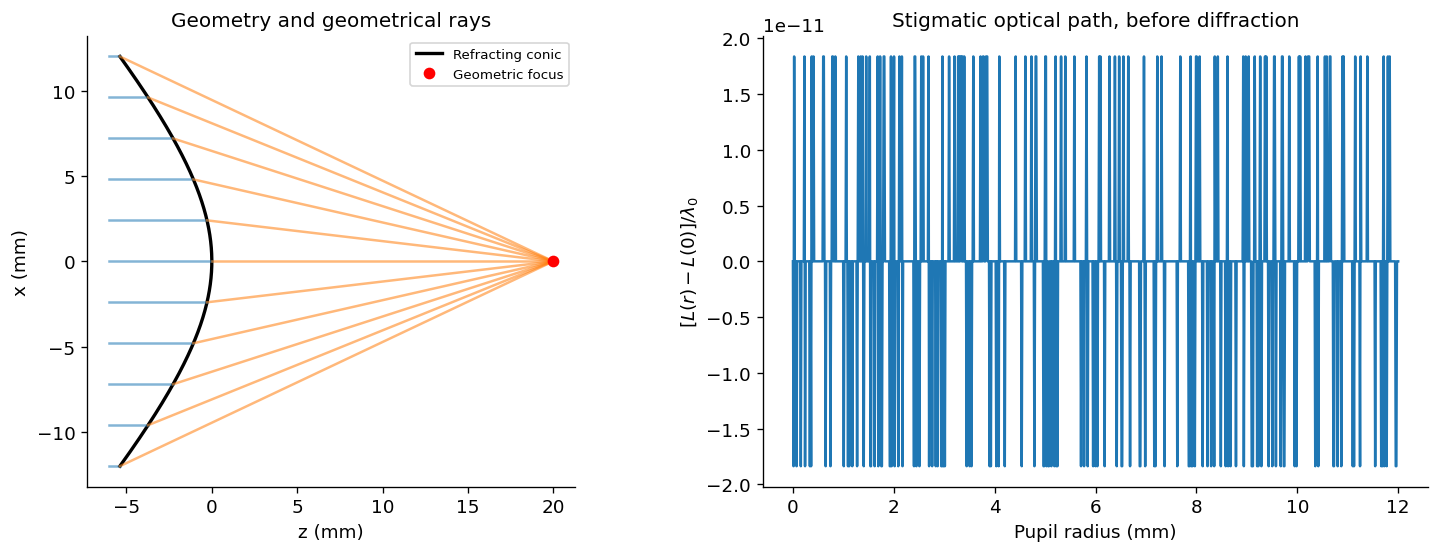

Image-side NA = 0.427353; aperture diameter / wavelength = 124,116
Fresnel traces and local-spectrum construction: 0.011 s


In [2]:
from time import perf_counter
from vecdiff import EvenAsphere, Medium, DielectricInterface, plane_wave, sample_surface, interface_transform
wavelength=193.368e-6  # mm
surface=EvenAsphere(curvature=-.1,conic=-2.25)
aperture=12.; focus=np.array([0.,0.,20.])
interface=DielectricInterface(surface,Medium(1.5),Medium())
sampling=sample_surface(surface,(0,aperture),(0,2*np.pi),48,96)
incoming=plane_wave(wavelength=wavelength,medium=Medium(1.5))
start=perf_counter()
result=interface_transform(incoming,interface,sampling)
radiation=result.transmitted
local=radiation.local_spectrum(focus,15*wavelength)
construction=perf_counter()-start
r=np.linspace(0,aperture,1001); sag=surface.sag(r)
opl=1.5*sag+np.sqrt(r*r+(focus[2]-sag)**2)
na=aperture/np.sqrt(aperture**2+(focus[2]-sag[-1])**2)
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
rfull=np.r_[-r[::-1],r]; zfull=surface.sag(abs(rfull))
axes[0].plot(zfull,rfull,'k',lw=2,label='Refracting conic')
for rho in np.linspace(-aperture,aperture,11):
    z=surface.sag(abs(rho))
    axes[0].plot([-6,z],[rho,rho],color='tab:blue',alpha=.55)
    axes[0].plot([z,focus[2]],[rho,0],color='tab:orange',alpha=.55)
axes[0].plot(focus[2],0,'ro',label='Geometric focus')
axes[0].set(xlabel='z (mm)',ylabel='x (mm)',title='Geometry and geometrical rays',aspect='equal'); axes[0].legend(fontsize=8)
axes[1].plot(r,(opl-opl[0])/wavelength)
axes[1].set(xlabel='Pupil radius (mm)',ylabel=r'$[L(r)-L(0)]/\lambda_0$',title='Stigmatic optical path, before diffraction')
show(fig,'03_stigmatic_geometry')
assert np.ptp(opl)/wavelength < 1e-8
print(f'Image-side NA = {na:.6f}; aperture diameter / wavelength = {2*aperture/wavelength:,.0f}')
print(f'Fresnel traces and local-spectrum construction: {construction:.3f} s')

## 2. Evaluate the focal electric and magnetic fields
The local expansion is built from the **computed equivalent currents** on the
surface, with no Richards–Wolf pupil. It is restricted to a ball around the
focus and carries a bound on its radiation-kernel approximation. Coordinates
in the following plots are converted from mm to µm.

Both transverse and meridional maps use the same focal total-norm peak as
normalization. Each component has an explicit colorbar; the total is not
silently substituted for $E_x$.

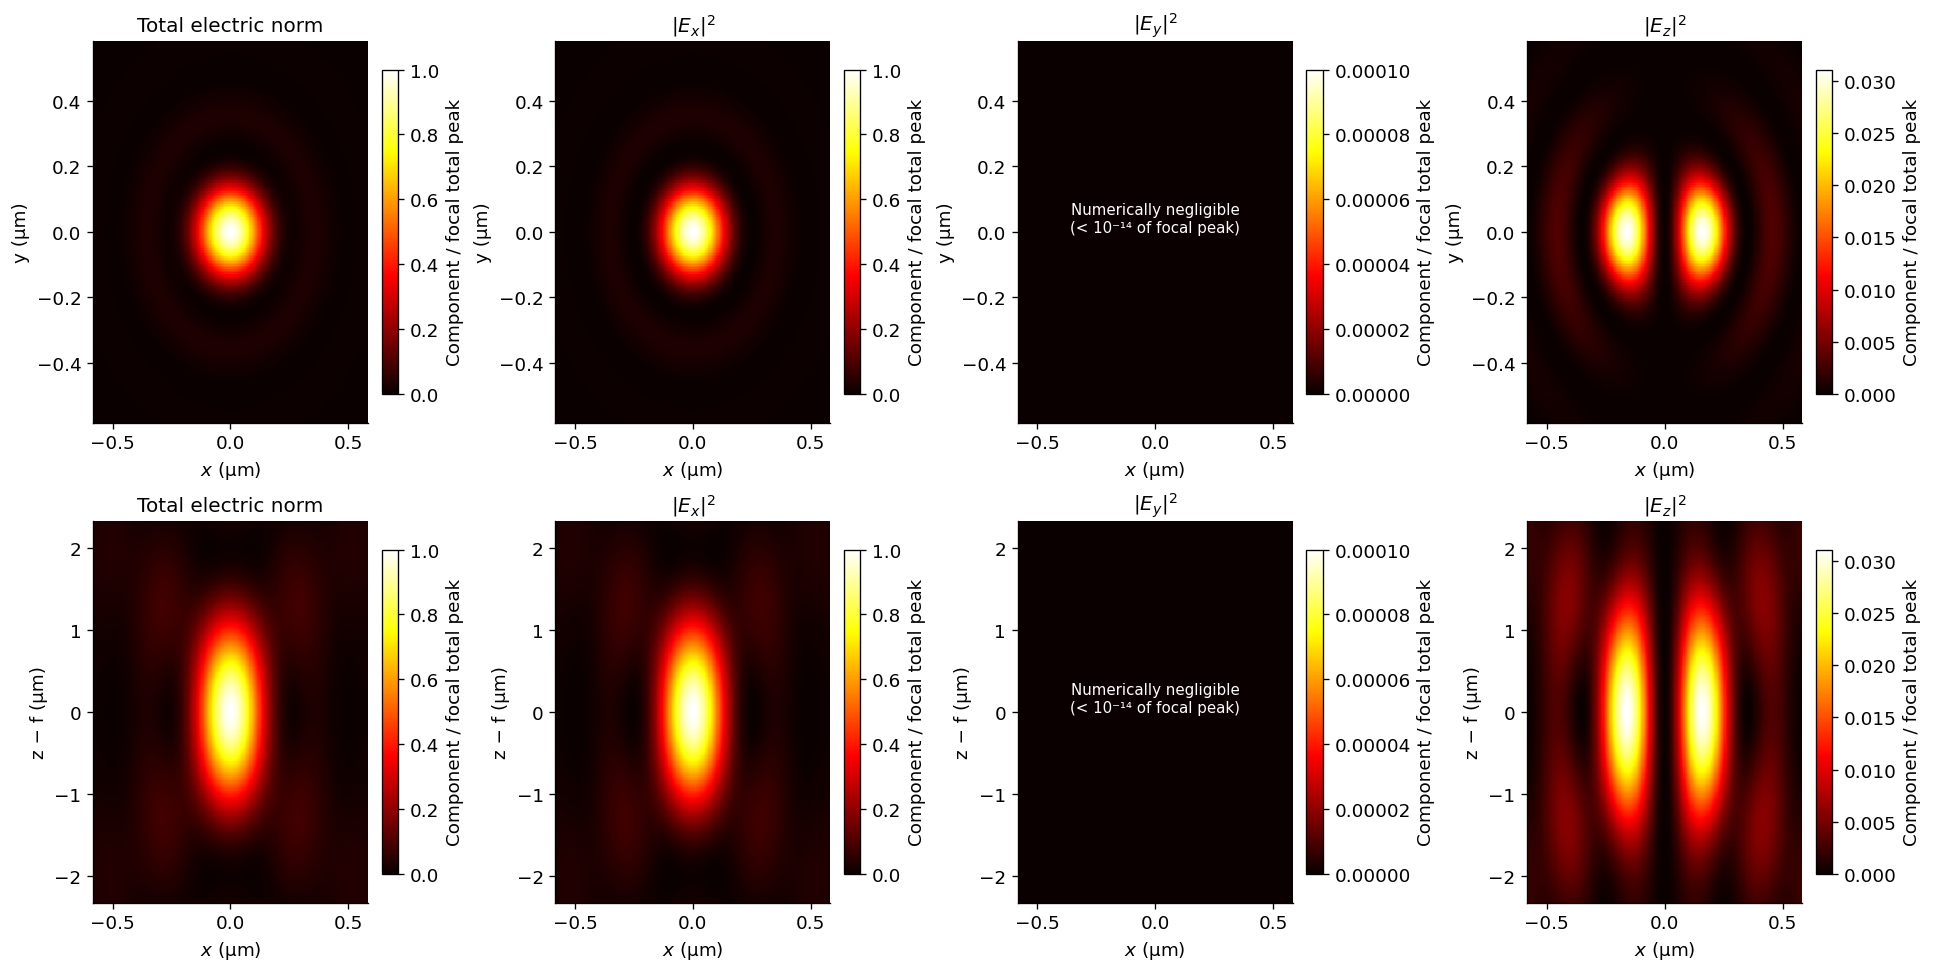

135,442 E/H observations: 0.679 s


In [3]:
x=np.linspace(-3,3,241)*wavelength
z=np.linspace(-12,12,321)*wavelength
X,Y=np.meshgrid(x,x); XM,Z=np.meshgrid(x,z)
xy=focus+np.stack((X,Y,0*X),axis=-1)
xz=focus+np.stack((XM,0*XM,Z),axis=-1)
start=perf_counter(); e,h=local.evaluate(xy,backend='nufft'); em,hm=local.evaluate(xz,backend='nufft')
seconds=perf_counter()-start
peak=np.sum(abs(e)**2,axis=-1).max()
fig,axes=plt.subplots(2,4,figsize=(16,8),layout='constrained')
for row,field,xx,yy,vertical in [(0,e,x*1e3,x*1e3,'y (µm)'),(1,em,x*1e3,z*1e3,'z − f (µm)')]:
    for col in range(4):
        values=np.sum(abs(field)**2,axis=-1) if col==0 else abs(field[...,col-1])**2
        title=['Total electric norm',r'$|E_x|^2$',r'$|E_y|^2$',r'$|E_z|^2$'][col]
        scalar_map(fig,axes[row,col],values/peak,xx,yy,title,
                   ylabel=vertical,label='Component / focal total peak',vmax=max(np.max(values)/peak,1e-4))
        if np.max(values)/peak < 1e-14:
            axes[row,col].text(.5,.5,'Numerically negligible\n(< 10⁻¹⁴ of focal peak)',transform=axes[row,col].transAxes,ha='center',color='white',fontsize=9)
show(fig,'03_stigmatic_vector_fields')
print(f'{e.shape[0]*e.shape[1]+em.shape[0]*em.shape[1]:,} E/H observations: {seconds:.3f} s')

## 3. Measure the focal spot and polarization
The x/y line widths reveal the anisotropy of a linearly polarized high-NA focus.
Encircled energy below means the integral of the **normal Poynting flux** over
a disk, divided by the flux in the finite displayed square. It is not a claim
that this square captures all radiated power.

The second polarization map repeats the same Fresnel calculation with circular
input. Ellipses are drawn only where the transverse norm exceeds 1% of its peak;
phase and polarization at field zeros are undefined.

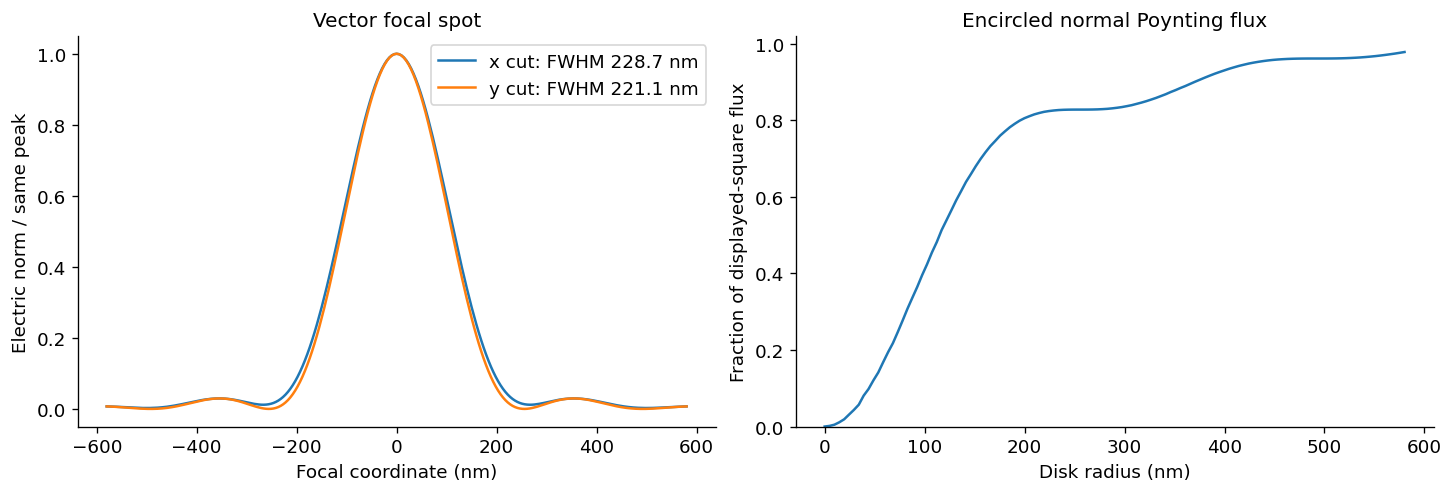

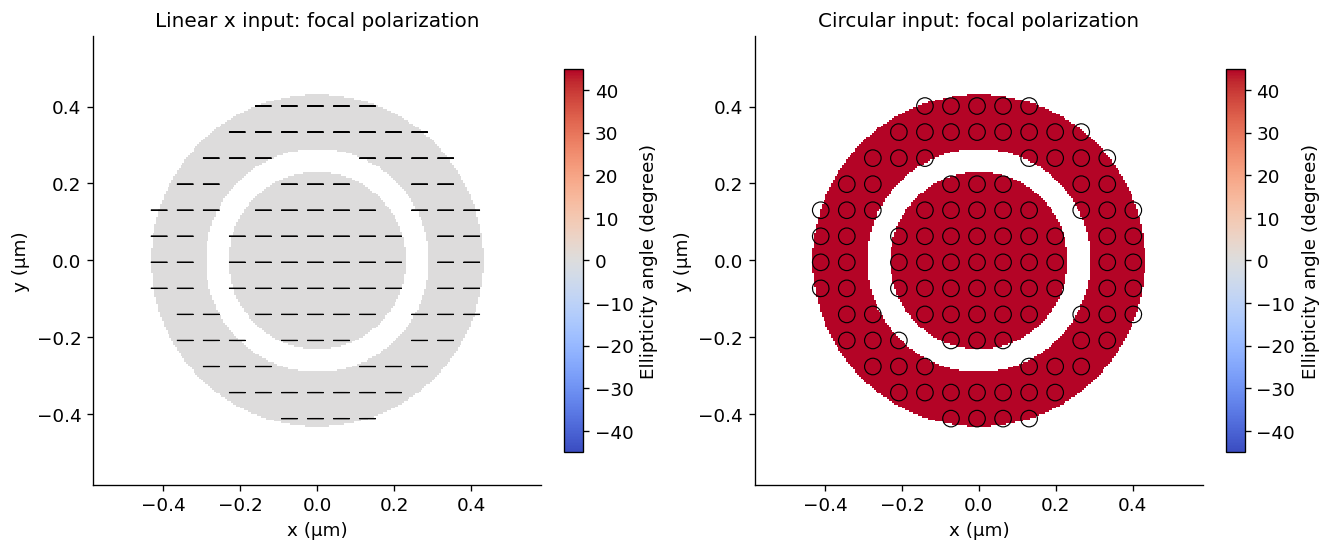

In [4]:
from vecdiff.observables.electromagnetism import poynting
intensity=np.sum(abs(e)**2,axis=-1); mid=len(x)//2
wx=fwhm(x*1e6,intensity[mid]); wy=fwhm(x*1e6,intensity[:,mid])
flux=poynting(e,h)[...,2]; radii=np.linspace(0,3*wavelength,120)
encircled=[np.sum(flux[X*X+Y*Y<=rr*rr])/np.sum(flux) for rr in radii]
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
axes[0].plot(x*1e6,intensity[mid]/peak,label=f'x cut: FWHM {wx:.1f} nm')
axes[0].plot(x*1e6,intensity[:,mid]/peak,label=f'y cut: FWHM {wy:.1f} nm')
axes[0].set(xlabel='Focal coordinate (nm)',ylabel='Electric norm / same peak',title='Vector focal spot'); axes[0].legend()
axes[1].plot(radii*1e6,encircled)
axes[1].set(xlabel='Disk radius (nm)',ylabel='Fraction of displayed-square flux',title='Encircled normal Poynting flux',ylim=(0,1.02))
show(fig,'03_spot_metrics')
circular=plane_wave(wavelength=wavelength,medium=Medium(1.5),polarization=np.array([1,1j,0])/np.sqrt(2))
crad=interface_transform(circular,interface,sampling).transmitted
ce,_=crad.local_spectrum(focus,15*wavelength).evaluate(xy,backend='nufft')
fig,axes=plt.subplots(1,2,figsize=(11,4.5),layout='constrained')
polarization_map(fig,axes[0],e,x*1e3,x*1e3,title='Linear x input: focal polarization')
polarization_map(fig,axes[1],ce,x*1e3,x*1e3,title='Circular input: focal polarization')
show(fig,'03_stigmatic_polarization')

## 4. Verify the speed–accuracy tradeoff with complex E and H
Compare at fixed off-axis and defocused points without fitting phase or
amplitude. Three controls have different meanings: local versus full kernel,
surface quadrature refinement, and NUFFT versus direct plane-wave summation.
The bound covers only the first of these. None measures the error of the
local Fresnel boundary approximation against a globally solved dielectric.

Local / full radiation kernel: 0.000111456
48×96 / 72×144 source nodes: 1.72265e-11
NUFFT / direct spectral sum: 9.85336e-11
Absolute E bound / focal peak amplitude: 0.8158%


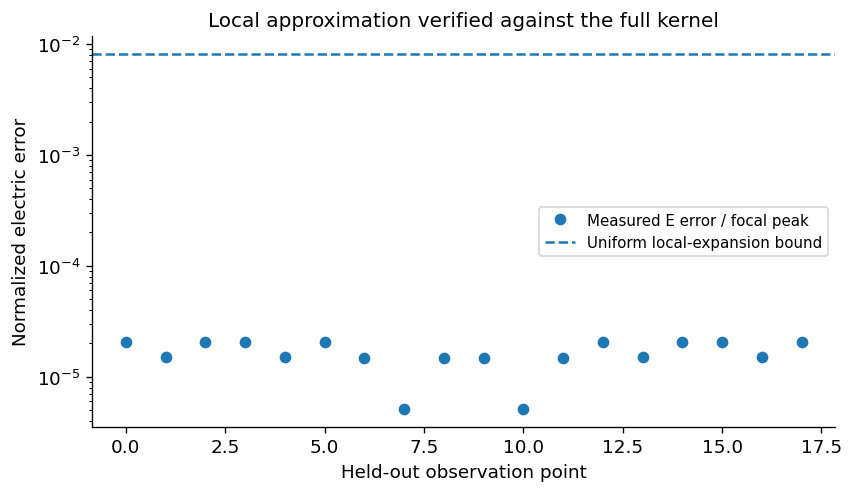

In [5]:
points=focus+wavelength*np.array([[a,b,c] for a in [-3,0,3] for b in [-1,1] for c in [-12,0,12]])
def relative(pair,reference):
    return np.linalg.norm(np.concatenate([a-b for a,b in zip(pair,reference)],axis=-1))/np.linalg.norm(np.concatenate(reference,axis=-1))
exact=radiation.evaluate(points)
prediction=local.evaluate(points)
refined_sampling=sample_surface(surface,(0,aperture),(0,2*np.pi),72,144)
refined=interface_transform(incoming,interface,refined_sampling).transmitted.evaluate(points)
errors={'Local / full radiation kernel':relative(prediction,exact),
        '48×96 / 72×144 source nodes':relative(exact,refined),
        'NUFFT / direct spectral sum':relative(local.evaluate(points,backend='nufft'),prediction)}
for name,value in errors.items(): print(f'{name}: {value:.6g}')
print(f'Absolute E bound / focal peak amplitude: {local.electric_error_bound/np.sqrt(peak):.4%}')
assert errors['Local / full radiation kernel'] < 3e-4
assert errors['48×96 / 72×144 source nodes'] < 1e-7
assert errors['NUFFT / direct spectral sum'] < 1e-8
fig,ax=plt.subplots(figsize=(7,4),layout='constrained')
ax.semilogy(range(len(points)),np.linalg.norm(prediction[0]-exact[0],axis=-1)/np.sqrt(peak),'o',label='Measured E error / focal peak')
ax.axhline(local.electric_error_bound/np.sqrt(peak),ls='--',label='Uniform local-expansion bound')
ax.set(xlabel='Held-out observation point',ylabel='Normalized electric error',title='Local approximation verified against the full kernel'); ax.legend(fontsize=9)
show(fig,'03_kernel_accuracy')

**Result to use:** a geometrically stigmatic dielectric exit surface produces a
computed vector focus, with meridional structure, polarization and measured
spot widths. Its fast local spectrum is suitable for small focal observation
windows after the displayed controls. The full optical-system throughput,
entrance face, off-axis aberrations and global boundary error remain separate
physical questions.